In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

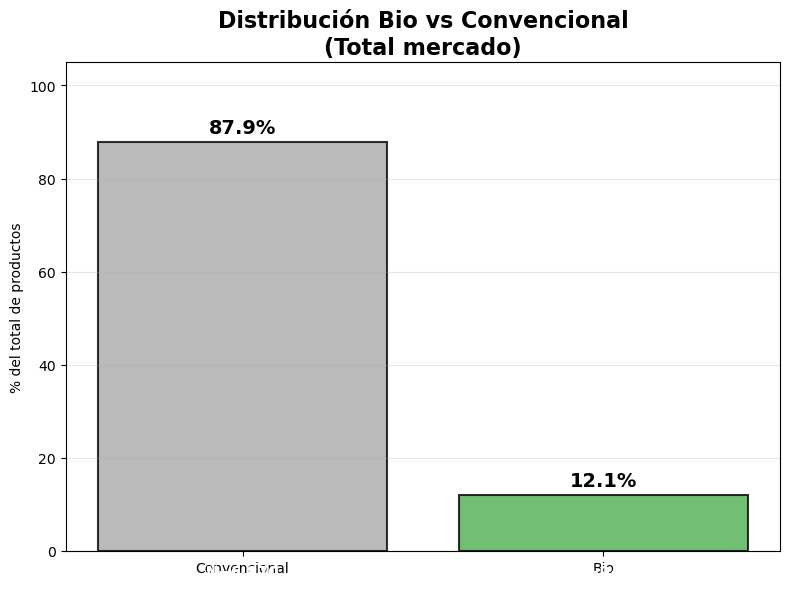

Distribución total Bio vs Convencional:
Convencional: 87.9% (N=6,870)
Bio:         12.1% (N=949)
Diferencia:  75.7 puntos


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preparar datos
foods["is_bio"] = foods["is_bio"].astype(str).str.lower().isin(["true", "1", "yes", "y"])

totales = foods["is_bio"].value_counts()
total_pct = totales / len(foods) * 100

# Gráfico de barras simple
plt.figure(figsize=(8, 6))
bars = plt.bar(['Convencional', 'Bio'], total_pct.values, 
               color=['#A9A9A9', '#4CAF50'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

# Porcentajes encima de barras (con 1 decimal)
for bar, pct in zip(bars, total_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{pct:.1f}%', ha='center', va='bottom', 
             fontweight='bold', fontsize=14)

plt.title('Distribución Bio vs Convencional\n(Total mercado)', fontsize=16, fontweight='bold')
plt.ylabel('% del total de productos')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Añadir valores absolutos debajo
for i, (tipo, count) in enumerate(totales.items()):
    plt.text(i, -3, f'N={count:,}', ha='center', va='top', 
             fontweight='bold', fontsize=11, color='white')

plt.tight_layout()
plt.show()

# Tabla resumen
print("Distribución total Bio vs Convencional:")
print(f"Convencional: {total_pct[False]:.1f}% (N={totales[False]:,})")
print(f"Bio:         {total_pct[True]:.1f}% (N={totales[True]:,})")
print(f"Diferencia:  {total_pct[False] - total_pct[True]:.1f} puntos")

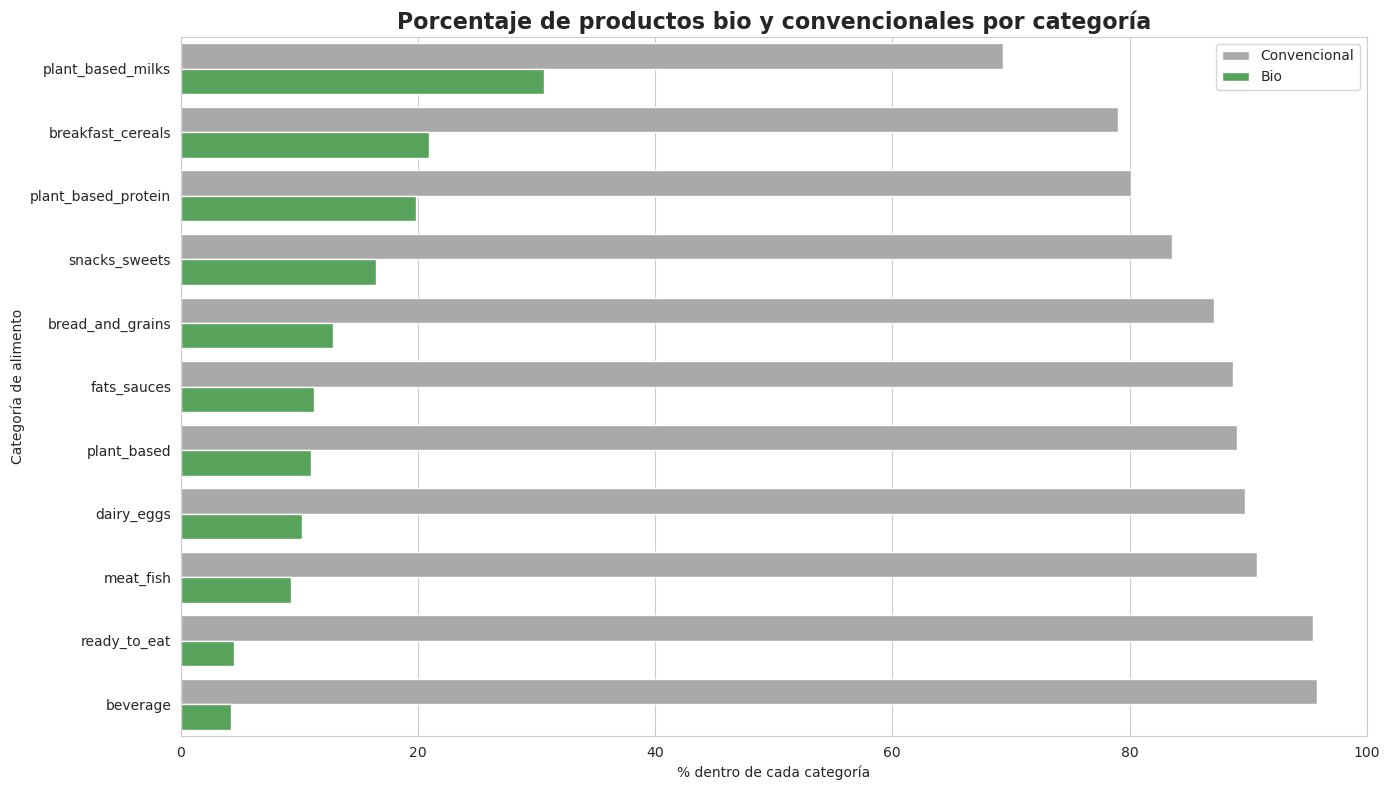

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

foods["is_bio"] = foods["is_bio"].astype(str).str.lower().isin(["true", "1", "yes", "y"])
foods["category_unified"] = (
    foods["category_unified"]
    .fillna("Sin categoría")
    .astype(str)
    .str.strip()
    .replace("", "Sin categoría")
)

top_n = 15
category_order = foods["category_unified"].value_counts().head(top_n).index
plot_df = foods[foods["category_unified"].isin(category_order)].copy()

# Porcentaje por categoría
pct = (
    plot_df.groupby(["category_unified", "is_bio"])
    .size()
    .unstack(fill_value=0)
)

pct = pct.div(pct.sum(axis=1), axis=0) * 100

# Ordenar de mayor a menor presencia bio
pct = pct.sort_values(by=True, ascending=False)

# Pasar a formato largo para seaborn
pct_long = pct.reset_index().melt(
    id_vars="category_unified",
    var_name="is_bio",
    value_name="pct"
)

pct_long["tipo"] = pct_long["is_bio"].map({True: "Bio", False: "Convencional"})

sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

sns.barplot(
    data=pct_long,
    y="category_unified",
    x="pct",
    hue="tipo",
    order=pct.index.tolist(),
    palette={"Bio": "#4CAF50", "Convencional": "#A9A9A9"}
)

plt.title("Porcentaje de productos bio y convencionales por categoría", fontsize=16, fontweight="bold")
plt.xlabel("% dentro de cada categoría")
plt.ylabel("Categoría de alimento")
plt.xlim(0, 100)
plt.legend(title="")
plt.tight_layout()
plt.show()

Distribución Nutri-Score Bio vs Conv:
nutriscore_grade          a          b          c          d          e
is_bio                                                                 
False             18.070467  14.683200  25.964010  21.336761  19.945562
True              19.675676  20.108108  26.378378  17.081081  16.756757

Distribución NOVA Bio vs Conv:
nova_group          1         2          3          4
is_bio                                               
False       10.702703  3.196911  24.401544  61.698842
True        14.193548  4.946237  41.720430  39.139785

Distribución Eco-Score Bio vs Conv:
ecoscore_grade          a          b          c          d          e
is_bio                                                               
False           20.886792  25.716981  17.415094  21.169811  14.811321
True            31.818182  30.844156  26.298701   8.116883   2.922078


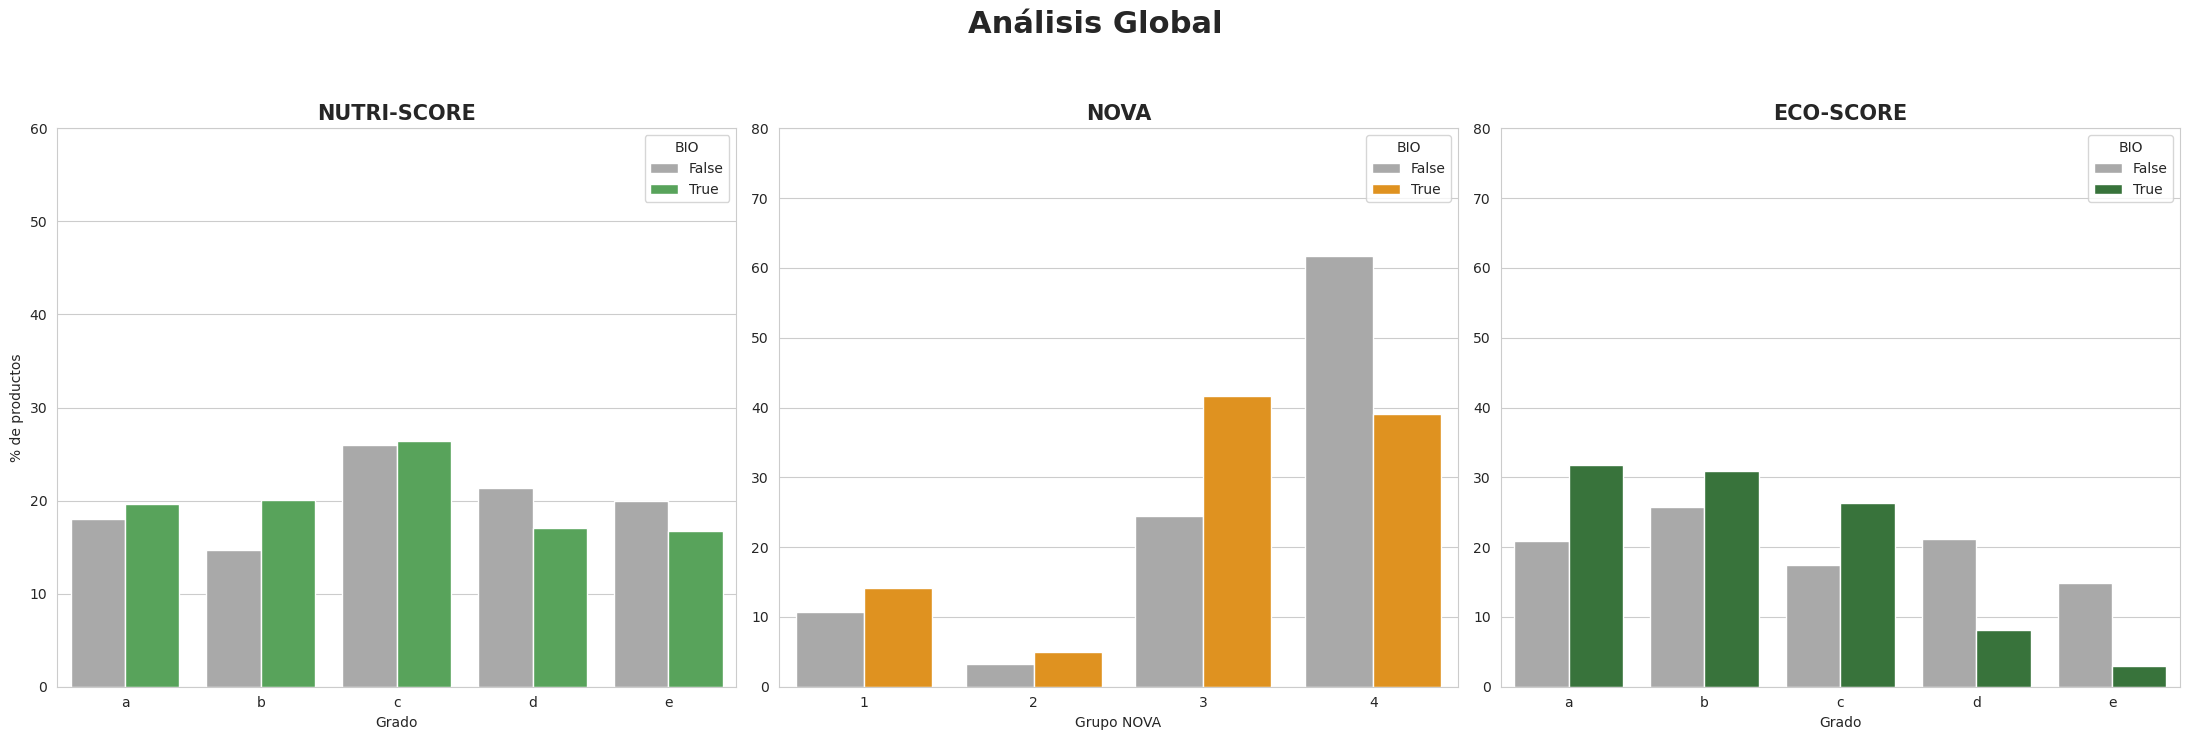

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define orders
order_ns = ['a', 'b', 'c', 'd', 'e']
order_nova = [1, 2, 3, 4]
order_eco = ['a', 'b', 'c', 'd', 'e']

# Setup Figure
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# 1. Nutri-Score General
sub_ns = foods[foods['nutriscore_grade'].isin(order_ns)]
pct_ns = sub_ns.groupby(['is_bio', 'nutriscore_grade']).size().unstack(fill_value=0)
pct_ns = pct_ns.div(pct_ns.sum(axis=1), axis=0) * 100
melt_ns = pct_ns.reindex(columns=order_ns).fillna(0).reset_index().melt(id_vars='is_bio', value_name='pct', var_name='grade')

sns.barplot(ax=axes[0], data=melt_ns, x='grade', y='pct', hue='is_bio', palette=['#A9A9A9', '#4CAF50'])
axes[0].set_title("NUTRI-SCORE", fontsize=15, fontweight='bold')
axes[0].set_ylabel("% de productos")
axes[0].set_xlabel("Grado")
axes[0].set_ylim(0, 60)
axes[0].legend(title='BIO')

# 2. NOVA General
sub_nova = foods[foods['nova_group'].isin(order_nova)]
pct_nova = sub_nova.groupby(['is_bio', 'nova_group']).size().unstack(fill_value=0)
pct_nova = pct_nova.div(pct_nova.sum(axis=1), axis=0) * 100
melt_nova = pct_nova.reindex(columns=order_nova).fillna(0).reset_index().melt(id_vars='is_bio', value_name='pct', var_name='grade')

sns.barplot(ax=axes[1], data=melt_nova, x='grade', y='pct', hue='is_bio', palette=['#A9A9A9', '#FF9800'])
axes[1].set_title("NOVA", fontsize=15, fontweight='bold')
axes[1].set_ylabel("")
axes[1].set_xlabel("Grupo NOVA")
axes[1].set_ylim(0, 80)
axes[1].legend(title='BIO')

# 3. Eco-Score General
sub_eco = foods[foods['ecoscore_grade'].isin(order_eco)]
pct_eco = sub_eco.groupby(['is_bio', 'ecoscore_grade']).size().unstack(fill_value=0)
pct_eco = pct_eco.div(pct_eco.sum(axis=1), axis=0) * 100
melt_eco = pct_eco.reindex(columns=order_eco).fillna(0).reset_index().melt(id_vars='is_bio', value_name='pct', var_name='grade')

sns.barplot(ax=axes[2], data=melt_eco, x='grade', y='pct', hue='is_bio', palette=['#A9A9A9', '#2E7D32'])
axes[2].set_title("ECO-SCORE", fontsize=15, fontweight='bold')
axes[2].set_ylabel("")
axes[2].set_xlabel("Grado")
axes[2].set_ylim(0, 80)
axes[2].legend(title='BIO')

plt.suptitle("Análisis Global", 
             fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()

# Summary stats for the response
print("Distribución Nutri-Score Bio vs Conv:")
print(pct_ns)
print("\nDistribución NOVA Bio vs Conv:")
print(pct_nova)
print("\nDistribución Eco-Score Bio vs Conv:")
print(pct_eco)

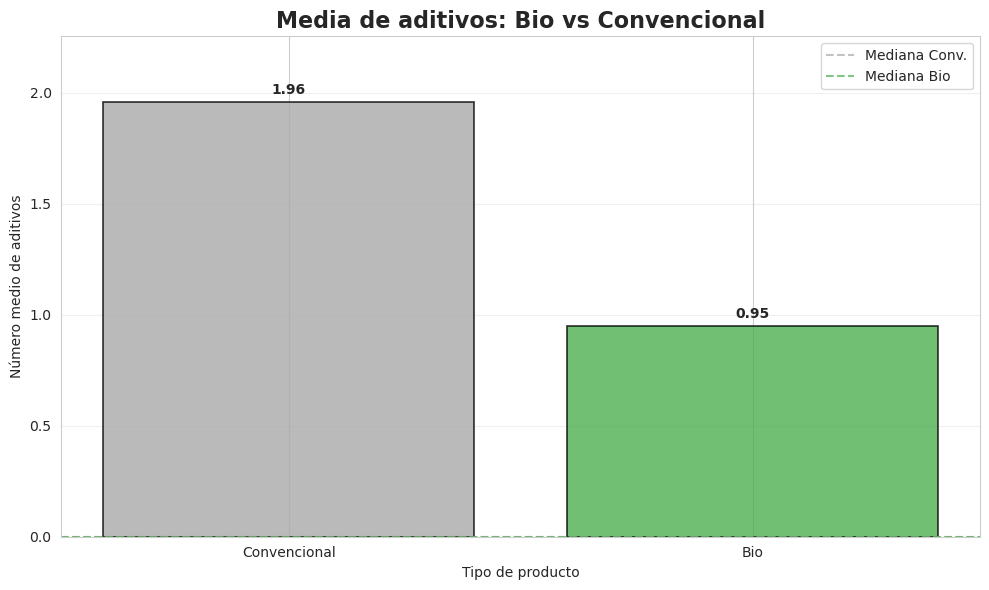

        mean  median  count
is_bio                     
False   1.96     0.0   6870
True    0.95     0.0    949


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos
foods['is_bio'] = foods['is_bio'].astype(str).str.lower().isin(['true','1','yes','y'])
foods['additive_count'] = pd.to_numeric(foods['additive_count'], errors='coerce').fillna(0)

# Estadísticas por tipo
stats = foods.groupby('is_bio')['additive_count'].agg(['mean', 'median', 'count']).round(2)
stats['tipo'] = ['Convencional', 'Bio']

# Gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(['Convencional', 'Bio'], stats['mean'], 
               color=['#A9A9A9', '#4CAF50'], 
               alpha=0.8, edgecolor='black', linewidth=1.2)

# Añadir valores encima de barras
for bar, valor in zip(bars, stats['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{valor:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Media de aditivos: Bio vs Convencional', fontsize=16, fontweight='bold')
plt.ylabel('Número medio de aditivos')
plt.xlabel('Tipo de producto')
plt.ylim(0, max(stats['mean']) * 1.15)
plt.grid(axis='y', alpha=0.3)

# Añadir mediana como línea
plt.axhline(y=stats.loc[False, 'median'], color='#A9A9A9', linestyle='--', alpha=0.7, label='Mediana Conv.')
plt.axhline(y=stats.loc[True, 'median'], color='#4CAF50', linestyle='--', alpha=0.7, label='Mediana Bio')
plt.legend()

plt.tight_layout()
plt.show()

# Tabla resumen
print(stats[['mean', 'median', 'count']])

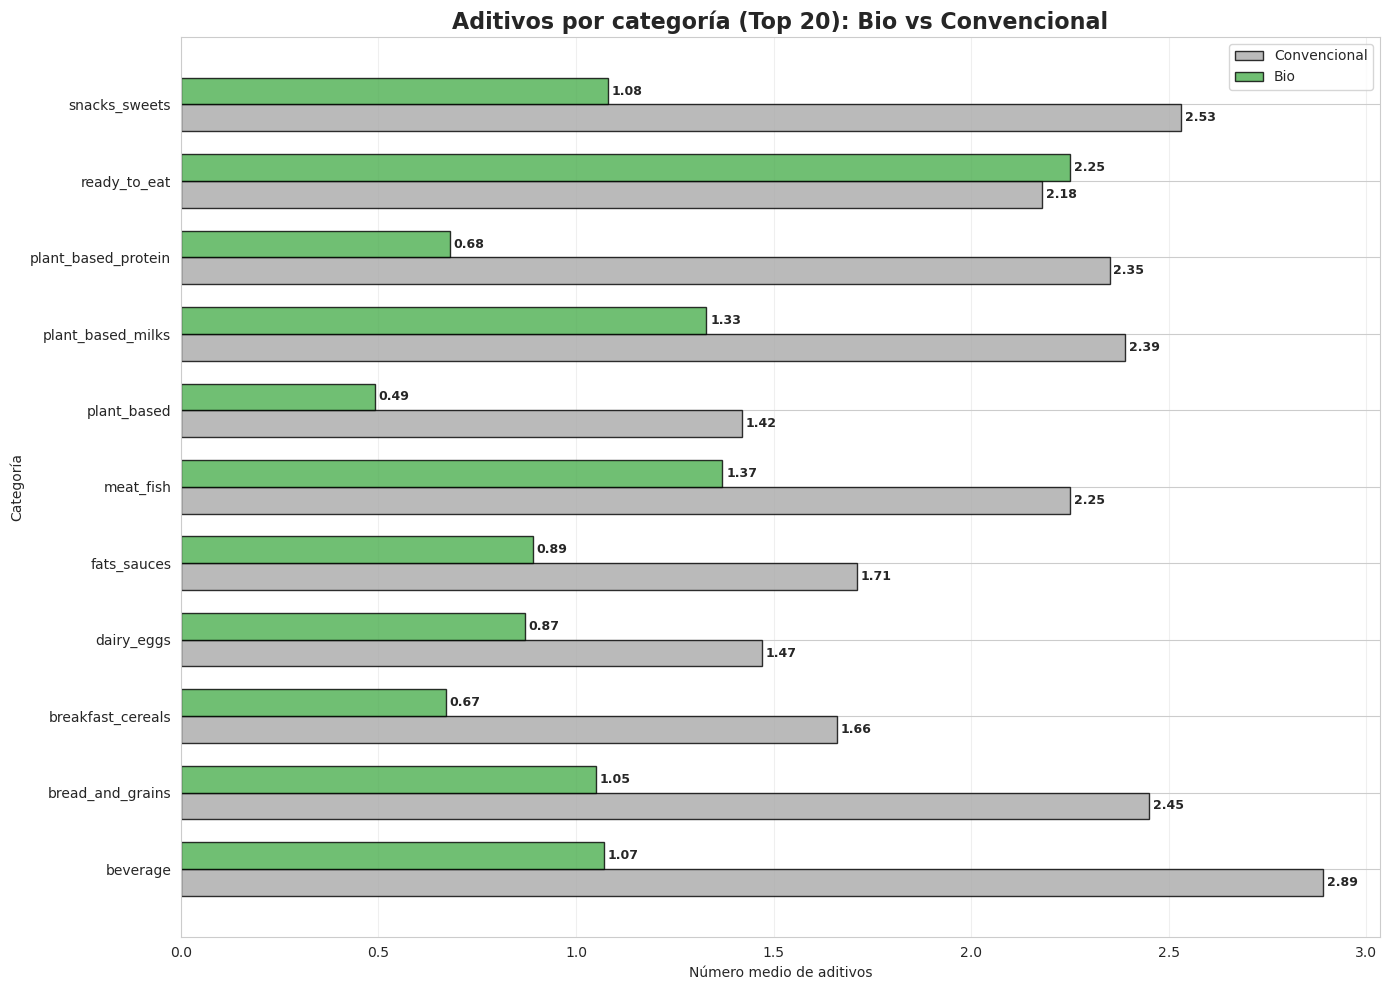

Media de aditivos por categoría y tipo (Top 20):
tipo                  Bio  Convencional
category_unified                       
beverage             1.07          2.89
bread_and_grains     1.05          2.45
breakfast_cereals    0.67          1.66
dairy_eggs           0.87          1.47
fats_sauces          0.89          1.71
meat_fish            1.37          2.25
plant_based          0.49          1.42
plant_based_milks    1.33          2.39
plant_based_protein  0.68          2.35
ready_to_eat         2.25          2.18
snacks_sweets        1.08          2.53


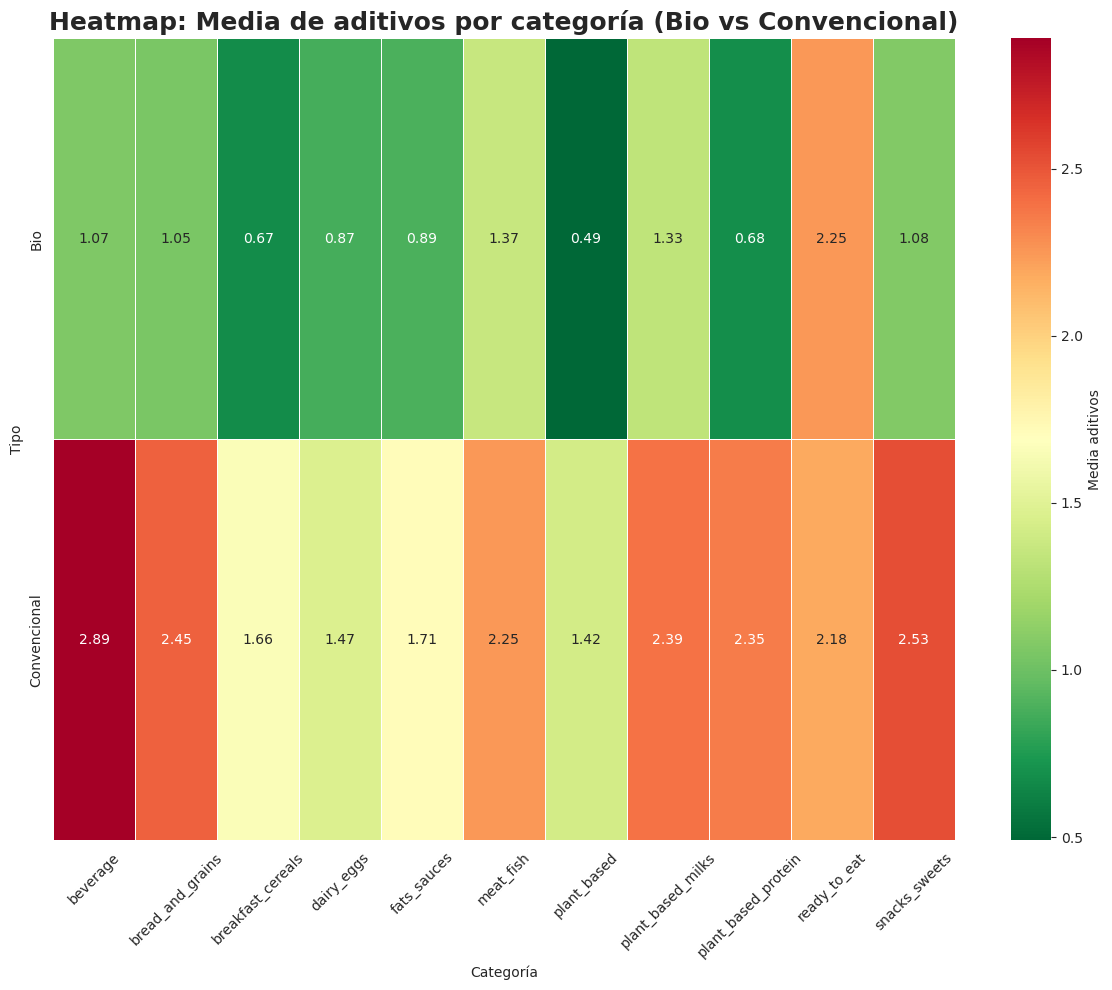

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparar datos (igual que el tuyo)
foods['is_bio'] = foods['is_bio'].astype(str).str.lower().isin(['true','1','yes','y'])
foods['additive_count'] = pd.to_numeric(foods['additive_count'], errors='coerce').fillna(0)
foods['category_unified'] = foods['category_unified'].fillna('Sin categoría').astype(str).str.strip()

top_n = 20
categorias_top = foods['category_unified'].value_counts().head(top_n).index
foods_filtrado = foods[foods['category_unified'].isin(categorias_top)].copy()

# Estadísticas por categoría y tipo
stats = foods_filtrado.groupby(['category_unified', 'is_bio'])['additive_count'].agg(['mean', 'median', 'count']).round(2)
stats = stats.reset_index()
stats['tipo'] = stats['is_bio'].map({False: 'Convencional', True: 'Bio'})

# Pivot para barras agrupadas
pivot_mean = stats.pivot(index='category_unified', columns='tipo', values='mean').fillna(0)

# Gráfico de barras agrupadas HORIZONTAL 
plt.figure(figsize=(14, 10))
x = range(len(pivot_mean))
width = 0.35

bars1 = plt.barh([i - width/2 for i in x], pivot_mean['Convencional'], width, 
                 label='Convencional', color='#A9A9A9', alpha=0.8, edgecolor='black')
bars2 = plt.barh([i + width/2 for i in x], pivot_mean['Bio'], width, 
                 label='Bio', color='#4CAF50', alpha=0.8, edgecolor='black')

# Valores encima de barras
for bars, valores in [(bars1, pivot_mean['Convencional']), (bars2, pivot_mean['Bio'])]:
    for bar, valor in zip(bars, valores):
        plt.text(valor + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{valor:.2f}', ha='left', va='center', fontweight='bold', fontsize=9)

plt.xlabel('Número medio de aditivos')
plt.ylabel('Categoría')
plt.title('Aditivos por categoría (Top 20): Bio vs Convencional', fontsize=16, fontweight='bold')
plt.yticks(x, pivot_mean.index, fontsize=10)
plt.legend(loc='upper right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print("Media de aditivos por categoría y tipo (Top 20):")
print(pivot_mean.round(2))

# *** Heatmap para todas las categorías ***
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_mean.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Media aditivos'}, linewidths=0.5)
plt.title('Heatmap: Media de aditivos por categoría (Bio vs Convencional)',fontsize=18, fontweight='bold')
plt.ylabel('Tipo')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

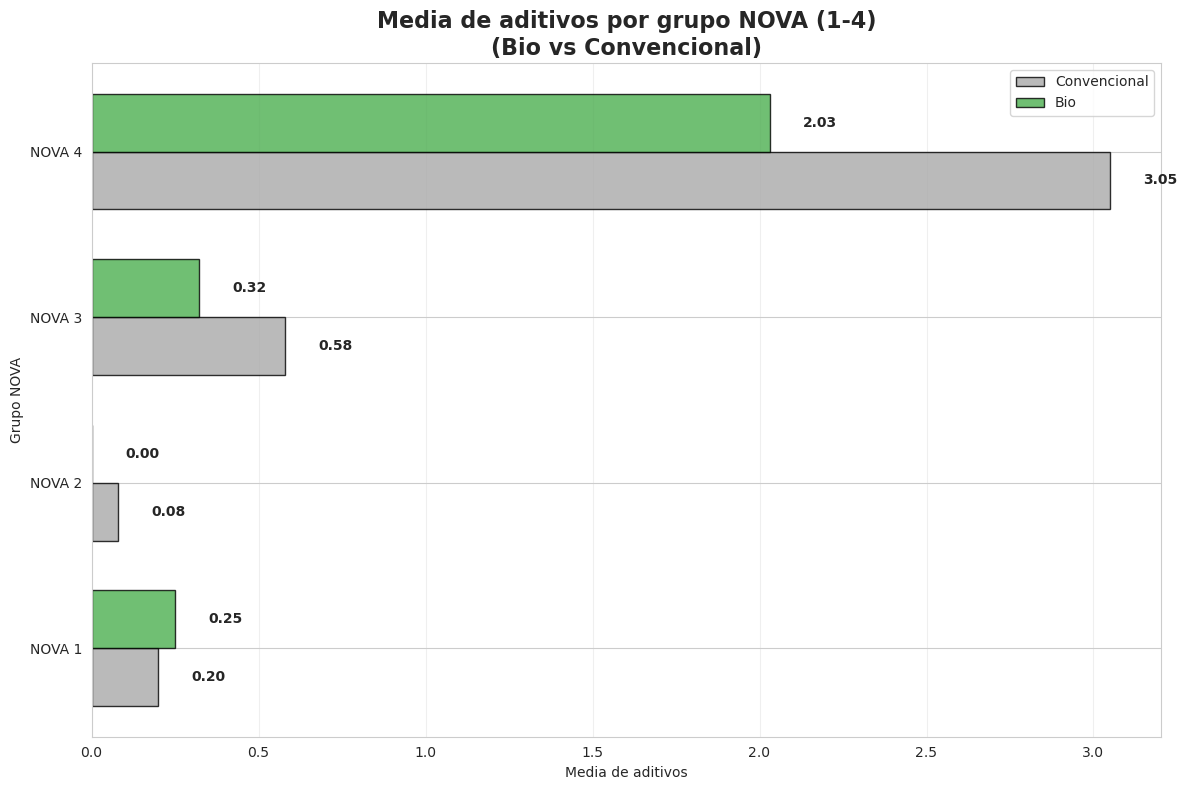

Media de aditivos por NOVA (SIN NOVA 0):
tipo         Bio  Convencional
nova_group                    
1           0.25          0.20
2           0.00          0.08
3           0.32          0.58
4           2.03          3.05


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Preparar datos
foods['is_bio'] = foods['is_bio'].astype(str).str.lower().isin(['true','1','yes','y'])
foods['additive_count'] = pd.to_numeric(foods['additive_count'], errors='coerce').fillna(0)
foods['nova_group'] = pd.to_numeric(foods['nova_group'], errors='coerce').fillna(0).astype(int)

# *** QUITAR NOVA 0 ***
plot_df = foods[foods['nova_group'] > 0].copy()

# Top NOVA 
top_nova = plot_df['nova_group'].value_counts().head(10)
plot_df = plot_df[plot_df['nova_group'].isin(top_nova.index)].copy()

# Estadísticas
stats = plot_df.groupby(['nova_group', 'is_bio'])['additive_count'].agg(['mean', 'median', 'count']).round(2)
stats = stats.reset_index()
stats['tipo'] = stats['is_bio'].map({False: 'Convencional', True: 'Bio'})

# Pivot
pivot_mean = stats.pivot(index='nova_group', columns='tipo', values='mean').fillna(0)

# Gráfico barras 
plt.figure(figsize=(12, 8))
x = range(len(pivot_mean))
width = 0.35

bars1 = plt.barh([i - width/2 for i in x], pivot_mean['Convencional'], width, 
                 label='Convencional', color='#A9A9A9', alpha=0.8, edgecolor='black')
bars2 = plt.barh([i + width/2 for i in x], pivot_mean['Bio'], width, 
                 label='Bio', color='#4CAF50', alpha=0.8, edgecolor='black')

# Valores
for bars, valores in [(bars1, pivot_mean['Convencional']), (bars2, pivot_mean['Bio'])]:
    for bar, valor in zip(bars, valores):
        plt.text(valor + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{valor:.2f}', ha='left', va='center', fontweight='bold')

plt.xlabel('Media de aditivos')
plt.ylabel('Grupo NOVA')
plt.title('Media de aditivos por grupo NOVA (1-4)\n(Bio vs Convencional)', fontsize=16, fontweight='bold')
plt.yticks(x, [f'NOVA {int(i)}' for i in pivot_mean.index])
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla
print("Media de aditivos por NOVA (SIN NOVA 0):")
print(pivot_mean.round(2))


